# Setup

In [1]:
from pathlib import Path

from PIL import Image
from IPython.display import Video

import torch
from ultralytics import YOLO

In [2]:
device = "cuda" if torch.cuda.is_available() else \
         "mps" if torch.backends.mps.is_available() else "cpu"

print(f"Dispositivo seleccionado para inferencia:\n{device}")

Dispositivo seleccionado para inferencia:
cuda


# Cargamos el MEJOR modelo

Que entrenamos con Fine-Tuning de YOLO

In [3]:
# 1. Cargamos el modelo especializado (usamos 'best.pt' que es el resultado del fine-tuning)
model_rl = YOLO("local/runs/detect/train/weights/best.pt")

# Importar imagen para inferencia

Es COMPLETAMENTE NUEVA, nunca antes vista para el modelo

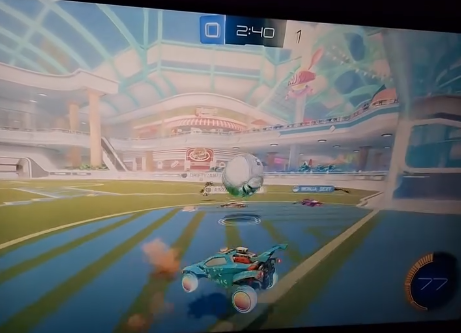

In [4]:
# 2. Usamos una imagen completamente nueva
IMAGE_PATH = r"local\assets\sample_images\rocket-league-testing.png"

img = Image.open(IMAGE_PATH)
img

# Inferencia (predecir)


0: 256x320 1 ball, 1 car, 108.5ms
Speed: 5.8ms preprocess, 108.5ms inference, 19.1ms postprocess per image at shape (1, 3, 256, 320)


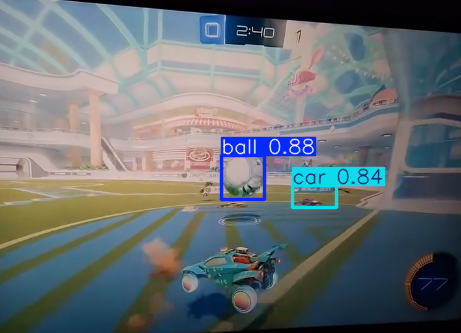

In [5]:
# 3. Ejecutamos la inferencia
# conf=0.5: Solo mostramos objetos con más del 50% de certeza
results = model_rl.predict(source=img, conf=0.7)

# 4. Visualizamos los resultados directamente en el notebook
Image.fromarray(results[0].plot()[..., ::-1])

# No te sorprendió?

In [7]:
VIDEO_PATH = r"local/assets/sample_videos/rocket_league_demo.mp4"

results_video = model_rl.predict(
    source=VIDEO_PATH, 
    save=True, 
    conf=0.4, 
    device=device,
)


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/637) c:\Users\efrai\OneDrive\Desktop\EF\Education\Professor\DL classes\uag-deep-learning\parcial_3\yolo\local\assets\sample_videos\rocket_league_demo.mp4: 256x320 3 cars, 20.6ms
video 1/1 (frame 2/637) c:\Users\efrai\OneDrive\Desktop\EF\Education\Professor\DL classes\uag-deep-learning\parcial_3\yolo\local\assets\sample_videos\rocket_league_demo.mp4: 256x320 2 cars, 19.3ms
video 1/1 (frame 3/637) c:\Users\efrai\OneDrive\Desktop\EF\Educatio